# **KSSC Final Project: Saturation & Hallucination Analysis in RAG [Experiment 2: Chunked Retrieval]**

1.   La Tania Nur Tenka (23/511404/PA/21787)*
2.   Raden Rara Garzetta Aleyda Harimurti (23/511422/PA/21793)*
3. Leilani Fitria Salimah Hadiwibowo (23/511451/PA/21798)*


## Setup

In [28]:
!pip install -q -U datasets sentence-transformers faiss-cpu \
    bitsandbytes accelerate transformers \
    rouge-score sacrebleu bert-score matplotlib pandas
print("Dependencies installed.")

Dependencies installed.


In [29]:
import os, re, json, random, time
import numpy as np, pandas as pd, torch
random.seed(42); np.random.seed(42); torch.manual_seed(42)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "set Runtime to T4")

GPU: Tesla T4


In [30]:
from google.colab import drive
drive.mount('/content/drive')
SAVE_DIR = "/content/drive/MyDrive/rag_kssc_chunked"
os.makedirs(SAVE_DIR, exist_ok=True)
print("Results will be saved to:", SAVE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Results will be saved to: /content/drive/MyDrive/rag_kssc_chunked


### Config

In [31]:
#SMOKE_TEST  = True
SMOKE_TEST  = False

SPLIT       = "validation"
EMBED_MODEL = "intfloat/multilingual-e5-base"
LLM_MODEL   = "Qwen/Qwen2.5-1.5B-Instruct"
MAX_NEW_TOKENS = 64
CHUNK_WORDS = 45      # chunk size (words); smaller -> harder retrieval -> stronger ramp
CHUNK_OVERLAP = 12

if SMOKE_TEST:
    SAMPLE_SIZE, N_UNANS, K_VALUES = 6, 2, [1, 3]
else:
    SAMPLE_SIZE, N_UNANS, K_VALUES = 150, 45, [1, 3, 5, 10]
print(f"SMOKE_TEST={SMOKE_TEST} | sample={SAMPLE_SIZE} (unans={N_UNANS}) | K={K_VALUES} | "
      f"chunk={CHUNK_WORDS}w/{CHUNK_OVERLAP}ov | LLM={LLM_MODEL}")

SMOKE_TEST=False | sample=150 (unans=45) | K=[1, 3, 5, 10] | chunk=45w/12ov | LLM=Qwen/Qwen2.5-1.5B-Instruct


---
## **Chunked Retrieval (+ Recall@K metric)**
**Owner:** La Tania Nur Tenka (23/511404/PA/21787).

Loading, **chunking**, embeddings, FAISS, Top-K, and chunk-level **Recall@K**.


### 1.1 Load, chunk, build gold-chunk mapping

In [32]:
from datasets import load_dataset
raw = load_dataset("rifkiaputri/idk-mrc")
print("Splits:", list(raw.keys()))

Splits: ['train', 'validation', 'test']


In [33]:
def answer_texts(ans):
    if ans is None: return []
    if isinstance(ans, dict): return list(ans.get("text", []))
    if isinstance(ans, list):
        out = []
        for a in ans:
            if isinstance(a, dict) and "text" in a: out.append(a["text"])
            elif isinstance(a, str): out.append(a)
        return out
    return []

def chunk_text(text, max_words=CHUNK_WORDS, overlap=CHUNK_OVERLAP):
    w = text.split()
    if len(w) <= max_words: return [text]
    step = max_words - overlap; out = []
    for i in range(0, len(w), step):
        out.append(" ".join(w[i:i+max_words]))
        if i + max_words >= len(w): break
    return out

def _norm(s): return re.sub(r"\s+", " ", (s or "").lower()).strip()

# 1) unique paragraphs + their questions
paragraphs, ctx2pid = [], {}
def get_pid(ctx):
    if ctx not in ctx2pid:
        ctx2pid[ctx] = len(paragraphs); paragraphs.append(ctx)
    return ctx2pid[ctx]

raw_records = []
for row in raw[SPLIT]:
    pid = get_pid(row["context"])
    for qa in row["qas"]:
        ans = answer_texts(qa.get("answers"))
        raw_records.append({"qid": qa["id"], "question": qa["question"], "gold_doc_id": pid,
                            "is_impossible": bool(qa.get("is_impossible", False)),
                            "answer": ans[0] if ans else None})

# 2) chunk every paragraph -> corpus_texts (chunks) + PARA_OF mapping
corpus_texts, PARA_OF, para_to_chunks = [], [], {}
for pid, para in enumerate(paragraphs):
    cids = []
    for ch in chunk_text(para):
        PARA_OF.append(pid); cids.append(len(corpus_texts)); corpus_texts.append(ch)
    para_to_chunks[pid] = cids

# 3) mark gold chunks: those containing the answer (fallback = all chunks of the gold paragraph)
records = []
for r in raw_records:
    pid = r["gold_doc_id"]; a = _norm(r["answer"])
    gold = [c for c in para_to_chunks[pid] if a and a in _norm(corpus_texts[c])] or para_to_chunks[pid]
    records.append({**r, "gold_chunk_ids": gold})

with open(f"{SAVE_DIR}/corpus.json", "w", encoding="utf-8") as f:
    json.dump(corpus_texts, f, ensure_ascii=False)
print(f"Paragraphs: {len(paragraphs)} -> CHUNKS: {len(corpus_texts)} | "
      f"questions: {len(records)} ({sum(not r['is_impossible'] for r in records)} answerable) | "
      f"avg gold chunks/answerable: "
      f"{np.mean([len(r['gold_chunk_ids']) for r in records if not r['is_impossible']]):.2f}")

Paragraphs: 358 -> CHUNKS: 884 | questions: 764 (382 answerable) | avg gold chunks/answerable: 1.15


In [34]:
# Fixed evaluation sample (same across all K)
random.seed(42)
ans_pool = [r for r in records if not r["is_impossible"]]
un_pool  = [r for r in records if r["is_impossible"]]
n_un = min(N_UNANS, len(un_pool)); n_an = min(SAMPLE_SIZE - n_un, len(ans_pool))
sample = random.sample(ans_pool, n_an) + random.sample(un_pool, n_un)
random.shuffle(sample)
with open(f"{SAVE_DIR}/sample.json", "w", encoding="utf-8") as f:
    json.dump(sample, f, ensure_ascii=False)
print(f"Sample: {len(sample)} ({sum(not r['is_impossible'] for r in sample)} answerable, "
      f"{sum(r['is_impossible'] for r in sample)} unanswerable)")

Sample: 150 (105 answerable, 45 unanswerable)


### 1.2 Embed chunks + FAISS + retrieve

In [35]:
from sentence_transformers import SentenceTransformer
import faiss
embedder = SentenceTransformer(EMBED_MODEL, device="cuda" if torch.cuda.is_available() else "cpu")
doc_emb = embedder.encode(["passage: " + t for t in corpus_texts], batch_size=64,
                          normalize_embeddings=True, show_progress_bar=True, convert_to_numpy=True)
index = faiss.IndexFlatIP(doc_emb.shape[1]); index.add(doc_emb.astype(np.float32))
print("Index ready:", index.ntotal, "chunk vectors, dim", doc_emb.shape[1])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/14 [00:00<?, ?it/s]

Index ready: 884 chunk vectors, dim 768


In [36]:
def retrieve(question, K):
    q = embedder.encode(["query: " + question], normalize_embeddings=True,
                        convert_to_numpy=True).astype(np.float32)
    return index.search(q, K)[1][0].tolist()

# gold is CHUNK-level: a hit = any gold chunk appears in the retrieved set
def gold_hit(r, rids):
    s = set(rids)
    return any(c in s for c in r["gold_chunk_ids"])

# Metric
def recall_at_k(rows):
    a = [r for r in rows if not r["is_impossible"]]
    return np.mean([r["gold_retrieved"] for r in a]) if a else 0.0

for K in K_VALUES:
    hits = [gold_hit(r, retrieve(r["question"], K)) for r in sample if not r["is_impossible"]]
    print(f"Recall@{K:<2} (pre-check): {np.mean(hits):.3f}")

Recall@1  (pre-check): 0.895
Recall@3  (pre-check): 0.971
Recall@5  (pre-check): 0.990
Recall@10 (pre-check): 0.990


---
## **Generation (+ Citation Accuracy metric)**
**Owner:** Rr. Garzetta Aleyda Harimurti (23/511422/PA/21793).

4-bit LLM, grounded few-shot prompt, parsing, chunk-aware **Citation Accuracy**.


### 2.1 Load LLM (4-bit)

In [37]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                         bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True)
tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL)
model = AutoModelForCausalLM.from_pretrained(LLM_MODEL, quantization_config=bnb,
                                             device_map="auto", torch_dtype=torch.float16).eval()
if tokenizer.pad_token is None: tokenizer.pad_token = tokenizer.eos_token
print("LLM loaded:", LLM_MODEL)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


LLM loaded: Qwen/Qwen2.5-1.5B-Instruct


### 2.2 Prompt (grounded few-shot, Indonesian), generation, parsing

In [38]:
# System prompt: the standing rules the model must follow on every question.
# We make the rules explicit because a small model needs strong, clear instructions.
SYSTEM_PROMPT = (
    "Anda adalah asisten tanya-jawab ekstraktif berbahasa Indonesia. Ikuti aturan ini:\n"
    "1. Jawab HANYA dengan informasi yang tertulis eksplisit di dokumen. "
    "Jangan memakai pengetahuan di luar dokumen.\n"
    "2. Jika dokumen tidak memuat jawaban, jawab tepat: 'Tidak tahu'.\n"
    "3. Jawab dengan informasi spesifik (nama/tanggal/frasa dari dokumen), "
    "BUKAN 'Ya' atau 'Tidak', walaupun pertanyaan diawali kata 'Apakah'.\n"
    "4. Akhiri dengan baris 'Sumber: [Dokumen X]'."
)

# Few shot example: show the model the exact format by example. Two normal answers
# and two refusals, so it learns both the layout AND when to say "Tidak tahu".
FEWSHOT = (
    "Contoh 1:\n"
    "Dokumen:\n[Dokumen 1] Ibu kota Indonesia adalah Jakarta.\n"
    "Pertanyaan: Apa ibu kota Indonesia?\n"
    "Jawaban: Jakarta\nSumber: [Dokumen 1]\n\n"
    "Contoh 2 (jawab dengan isi, bukan Ya/Tidak):\n"
    "Dokumen:\n[Dokumen 1] Penemu bola lampu adalah Thomas Edison.\n"
    "Pertanyaan: Apakah penemu bola lampu?\n"
    "Jawaban: Thomas Edison\nSumber: [Dokumen 1]\n\n"
    "Contoh 3 (informasi tidak ada di dokumen):\n"
    "Dokumen:\n[Dokumen 1] Candi Borobudur terletak di Magelang, Jawa Tengah.\n"
    "Pertanyaan: Pada tahun berapa Borobudur dibangun?\n"
    "Jawaban: Tidak tahu\nSumber: -\n\n"
    "Contoh 4 (pertanyaan di luar topik dokumen):\n"
    "Dokumen:\n[Dokumen 1] Sungai Kapuas adalah sungai terpanjang di Indonesia.\n"
    "Pertanyaan: Siapa tokoh utama novel Laskar Pelangi?\n"
    "Jawaban: Tidak tahu\nSumber: -\n\n"
)

def build_prompt(question, docs):
    blocks = "\n".join(f"[Dokumen {i+1}] {d}" for i, d in enumerate(docs))
    return (FEWSHOT +
            "Sekarang jawab pertanyaan berikut dengan format yang sama. "
            "Tulis dua baris: 'Jawaban:' lalu 'Sumber: [Dokumen X]'.\n"
            f"Dokumen:\n{blocks}\n\nPertanyaan: {question}\n")

@torch.inference_mode()
def generate(question, docs):
    msgs = [{"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": build_prompt(question, docs)}]
    enc = tokenizer.apply_chat_template(msgs, add_generation_prompt=True,
                                        return_tensors="pt", return_dict=True).to(model.device)
    out = model.generate(**enc, max_new_tokens=MAX_NEW_TOKENS, do_sample=False,
                         pad_token_id=tokenizer.pad_token_id)
    return tokenizer.decode(out[0][enc["input_ids"].shape[1]:], skip_special_tokens=True).strip()

def parse_generation(text):
    text = (text or "").strip(); answer = text
    m = re.search(r"(?:^|\n)\s*jawaban\s*:\s*(.*?)(?:\n\s*sumber\s*:|$)", text, flags=re.IGNORECASE | re.DOTALL)
    if m: answer = m.group(1).strip()
    else: answer = text.split("\n")[0].strip()
    ms = re.search(r"sumber\s*:(.*)", text, flags=re.IGNORECASE | re.DOTALL)
    src = ms.group(1) if ms else text
    cited = sorted(set(int(n) for n in re.findall(r"dokumen\s*(\d+)", src, flags=re.IGNORECASE)))
    return answer.strip(), cited

# Phrases that count as the model refusing / saying it doesn't know.
ABSTAIN = ["tidak tahu","tidak diketahui","tidak ada jawaban","tidak ditemukan","tidak dapat","tidak tersedia"]
def is_abstention(a):
    a = (a or "").lower().strip().strip(".!?\"' ")
    return a == "" or any(p in a for p in ABSTAIN)

# quick smoke test on one sampled question
d = sample[0]; dd = [corpus_texts[i] for i in retrieve(d["question"], 3)]
print("Q:", d["question"], "\n---\n", generate(d["question"], dd))

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Q: Berapakah luas negara wales pada 2012? 
---
 Jawaban: Tidak tahu
Sumber: [Dokumen 1]


### 2.3 Citation Accuracy (chunk-aware)

In [39]:
def cited_doc_ids(cited, rids):
    return [rids[n-1] for n in cited if 1 <= n <= len(rids)]

# Metric
def citation_correct(r):
    if not r["cited_doc_ids"]: return False
    gold = set(r["gold_chunk_ids"])
    if any(d in gold for d in r["cited_doc_ids"]): return True # fallback: also accept if a cited chunk actually contains the answer text
    g = (r["answer"] or "").lower()
    return bool(g) and any(g in corpus_texts[d].lower() for d in r["cited_doc_ids"])

def citation_accuracy(rows):
    a = [r for r in rows if not r["is_impossible"]]
    return np.mean([citation_correct(r) for r in a]) if a else 0.0
print("Citation functions ready (chunk-aware).")

Citation functions ready (chunk-aware).


---
## **Experiment: K sweep *(joint)***

In [40]:
all_runs = {}
for K in K_VALUES:
    print(f"\n=== K={K} ==="); rows, t0 = [], time.time()
    for j, r in enumerate(sample):
        rids = retrieve(r["question"], K)
        out = generate(r["question"], [corpus_texts[i] for i in rids])
        ans, cited = parse_generation(out)
        rows.append({**r, "retrieved_ids": rids, "cited_doc_ids": cited_doc_ids(cited, rids),
                     "gold_retrieved": gold_hit(r, rids), "pred": ans,
                     "abstained": is_abstention(ans), "raw_output": out})
        if (j+1) % 25 == 0: print(f"  {j+1}/{len(sample)} ({time.time()-t0:.0f}s)")
    all_runs[K] = rows
    with open(f"{SAVE_DIR}/runs_K{K}.json", "w", encoding="utf-8") as f:
        json.dump(rows, f, ensure_ascii=False, indent=2)
    print(f"  -> runs_K{K}.json ({time.time()-t0:.0f}s)")
print("\nDone. All runs saved to", SAVE_DIR)


=== K=1 ===
  25/150 (64s)
  50/150 (122s)
  75/150 (191s)
  100/150 (251s)
  125/150 (327s)
  150/150 (384s)
  -> runs_K1.json (384s)

=== K=3 ===
  25/150 (65s)
  50/150 (127s)
  75/150 (188s)
  100/150 (252s)
  125/150 (328s)
  150/150 (388s)
  -> runs_K3.json (388s)

=== K=5 ===
  25/150 (66s)
  50/150 (131s)
  75/150 (205s)
  100/150 (270s)
  125/150 (344s)
  150/150 (402s)
  -> runs_K5.json (402s)

=== K=10 ===
  25/150 (70s)
  50/150 (139s)
  75/150 (214s)
  100/150 (279s)
  125/150 (356s)
  150/150 (424s)
  -> runs_K10.json (424s)

Done. All runs saved to /content/drive/MyDrive/rag_kssc_chunked


---
## **Quality & hallucination eval**
**Owner:** Leilani Fitria Salimah Hadiwibowo (23/511451/PA/21798).

ROUGE/BLEU/BERTScore, hallucination, summary table, plots.


### 3.1 Quality + hallucination metrics

In [41]:
from rouge_score import rouge_scorer
import sacrebleu
from bert_score import score as bertscore
rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=False)

# >>> PERSON 3 METRICS <<<
def answer_quality(rows):
    a = [r for r in rows if not r["is_impossible"]]
    if not a: return 0.0, 0.0, 0.0
    pr = [r["pred"] for r in a]; rf = [r["answer"] for r in a]
    rl = np.mean([rouge.score(x, y)["rougeL"].fmeasure for y, x in zip(pr, rf)])
    bl = sacrebleu.corpus_bleu(pr, [rf]).score / 100.0
    _, _, bs = bertscore(pr, rf, lang="id", verbose=False, batch_size=32)
    return rl, bl, float(bs.mean())

def hallucination_rate(rows):
    u = [r for r in rows if r["is_impossible"]]
    return np.mean([not r["abstained"] for r in u]) if u else float("nan")
print("Quality & hallucination functions ready.")

Quality & hallucination functions ready.


### 3.2 Summary table

In [42]:
out_rows = []
for K, rows in all_runs.items():
    rl, bl, bs = answer_quality(rows)
    out_rows.append({"K": K, "ROUGE-L": rl, "BLEU": bl, "BERTScore-F1": bs,
                     "Citation-Acc": citation_accuracy(rows),
                     "Recall@K": recall_at_k(rows),
                     "Hallucination(unans)": hallucination_rate(rows)})
df = pd.DataFrame(out_rows).sort_values("K").reset_index(drop=True)
df.to_csv(f"{SAVE_DIR}/metrics_summary.csv", index=False)
df.round(4)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,K,ROUGE-L,BLEU,BERTScore-F1,Citation-Acc,Recall@K,Hallucination(unans)
0,1,0.4591,0.2325,0.7764,0.8667,0.8952,0.5556
1,3,0.4656,0.2644,0.7824,0.8286,0.9714,0.6000
2,5,0.4626,0.3113,0.7790,0.8286,0.9905,0.6000
3,10,0.4697,0.3454,0.7844,0.7619,0.9905,0.6222


### 3.3 Plots

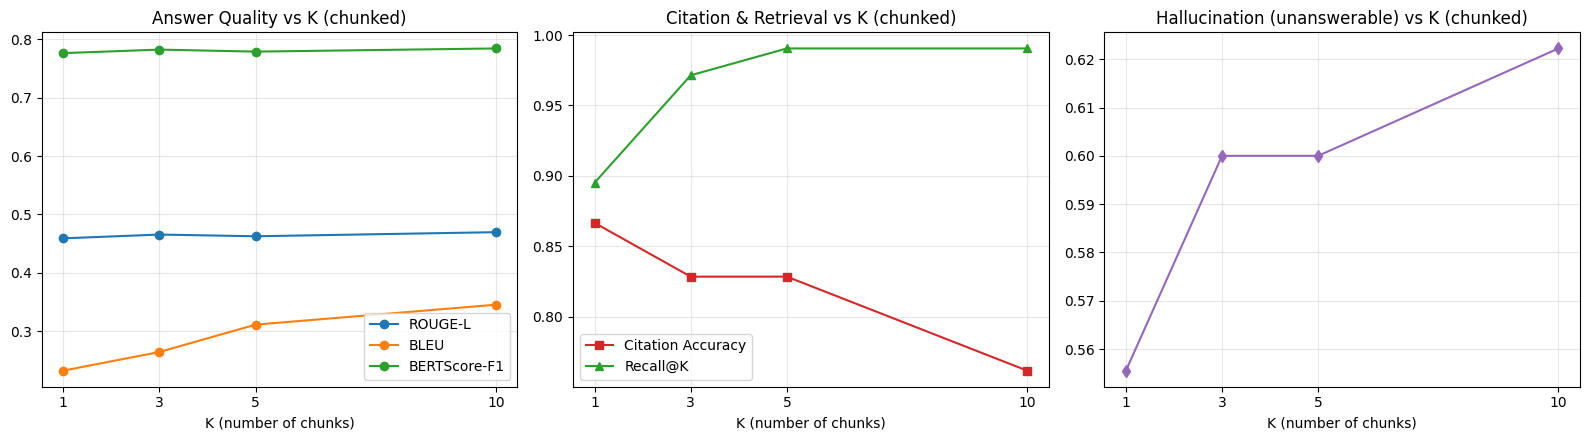

In [43]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
for c in ["ROUGE-L","BLEU","BERTScore-F1"]: ax[0].plot(df["K"], df[c], marker="o", label=c)
ax[0].set_title("Answer Quality vs K (chunked)"); ax[0].legend(); ax[0].grid(alpha=.3); ax[0].set_xticks(df["K"])
ax[1].plot(df["K"], df["Citation-Acc"], marker="s", color="tab:red", label="Citation Accuracy")
ax[1].plot(df["K"], df["Recall@K"], marker="^", color="tab:green", label="Recall@K")
ax[1].set_title("Citation & Retrieval vs K (chunked)"); ax[1].legend(); ax[1].grid(alpha=.3); ax[1].set_xticks(df["K"])
ax[2].plot(df["K"], df["Hallucination(unans)"], marker="d", color="tab:purple")
ax[2].set_title("Hallucination (unanswerable) vs K (chunked)"); ax[2].grid(alpha=.3); ax[2].set_xticks(df["K"])
for a in ax: a.set_xlabel("K (number of chunks)")
plt.tight_layout(); plt.savefig(f"{SAVE_DIR}/plots.png", dpi=150, bbox_inches="tight"); plt.show()

### 3.4 Qualitative examples

In [44]:
K = max(K_VALUES)
print(">> HALLUCINATION (unanswerable but answered):")
found = False
for r in all_runs[K]:
    if r["is_impossible"] and not r["abstained"]:
        print("  Q:", r["question"], "\n  pred:", r["pred"]); found = True; break
if not found: print("  (none at this K)")
print("\n>> WRONG CITATION (gold chunk retrieved but cited wrong):")
found = False
for r in all_runs[K]:
    if (not r["is_impossible"]) and r["gold_retrieved"] and not citation_correct(r):
        print("  Q:", r["question"], "\n  pred:", r["pred"], "| cited:", r["cited_doc_ids"]); found = True; break
if not found: print("  (none at this K)")

>> HALLUCINATION (unanswerable but answered):
  Q: Pada tahun berapa produksi anime pertama kali dilakukan? 
  pred: Pertanyaan ini bertentangan dengan konteks dokumen, karena dokumen tersebut membahas tentang anime dan tidak menyebutkan tahun produksi anime pertama kali.

>> WRONG CITATION (gold chunk retrieved but cited wrong):
  Q: apakah kabupaten terluas di Provinsi Jawa Timur? 
  pred: Kabupaten Banyuwangi | cited: [492]


---
## Comparing with Experiment 1, we can conclude that
RAG saturation is even observable depends on retrieval granularity. With coarse full-paragraph retrieval, Recall@1 ≈ 0.99, so the system saturates instantly and all quality curves are flat. Only with finer chunked retrieval does the expected saturation curve emerge: Recall@K climbs and plateaus around K=5, answer quality (BLEU) rises in step, while citation accuracy and faithfulness degrade as K grows, revealing the classic tension where more context helps retrieval recall but hurts generation faithfulness.

